# Análisis de un grupo de WhatsApp

Este proyecto analiza la actividad de un grupo de WhatsApp utilizando Python.

Los objetivos principales son:

- transformar el chat exportado a un formato tidy;
- anonimizar a los participantes;
- analizar la frecuencia de mensajes;
- estudiar palabras, emojis y stickers;
- analizar patrones por día de la semana y hora;
- identificar las palabras y adjetivos más utilizados;
- obtener conclusiones generales sobre la dinámica del grupo.

Los datos originales no se incluyen en el repositorio para proteger la privacidad de los participantes.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import re

In [2]:
CHAT_PATH = Path("Alumnos LCC UNISON") / "chat.txt"

print("Ruta:", CHAT_PATH)
print("¿Existe el archivo?:", CHAT_PATH.exists())

Ruta: Alumnos LCC UNISON\chat.txt
¿Existe el archivo?: True


In [3]:
with open(CHAT_PATH, "r", encoding="utf-8") as file:
    for _ in range(25):
        print(file.readline(), end="")

Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them.
[7/7/26, 5:13:41 PM] - Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.
[8/31/26, 1:25:42 PM] +52 1 662 467 9029: <image omitted> 🗣️🗣️🗣️🗣🗣🗣🗣🗣

🔴 Ya están los emparejamientos del torneo de Futbol 🗣

🔵 En el primer partido tendremos a los profes goleando a los de primero (o no)

🟢 En el tercero me veran a mi descalificando al Rodrigo y confinandolo a su puesto de árbitro.

🟡 Y en el cuarto partido los Legits van con los contendientes a la copa (segun ellos)

🟣 A las 5:00 en la cancha de psicología

Bracket:
https://challonge.com/es/k9wpsu13

Ubicación:
https://maps.app.goo.gl/iKJMhA8W1f2XRPak9
[8/31/26, 1:27:03 PM] +52 1 662 508 9779: <GIF omitted>
[8/31/26, 1:29:10 PM] +52 1 687 120 1981: Ya están las apuestas en Caliente ?
[8/31/26, 1:30:57 PM] +52 1 662 467 9029: Yaya
[8/31/26

## Lectura y transformación del chat

El archivo exportado por WhatsApp contiene mensajes con el formato:

`[fecha, hora] usuario: mensaje`

Algunos mensajes pueden contener varias líneas, por lo que es necesario identificar el inicio de cada mensaje y agrupar correctamente las líneas adicionales.

In [4]:
patron_inicio = re.compile(
    r'^\[(\d{1,2}/\d{1,2}/\d{2}),\s*'
    r'(\d{1,2}:\d{2}:\d{2}\s*[AP]M)\]\s*'
    r'-?\s*(.*)$'
)

patron_usuario = re.compile(
    r'^([^:]+):\s?(.*)$'
)

mensajes = []

with open(CHAT_PATH, "r", encoding="utf-8") as file:
    for linea in file:
        linea = linea.rstrip("\n")

        match = patron_inicio.match(linea)

        if match:
            fecha, hora, resto = match.groups()

            usuario_match = patron_usuario.match(resto)

            if usuario_match:
                usuario, contenido = usuario_match.groups()
            else:
                usuario = "Sistema"
                contenido = resto

            mensajes.append({
                "fecha": fecha,
                "hora": hora,
                "usuario": usuario.strip(),
                "mensaje": contenido.strip()
            })

        elif mensajes:
            mensajes[-1]["mensaje"] += "\n" + linea

In [5]:
df = pd.DataFrame(mensajes)

df.head()

,fecha,hora,usuario,mensaje
0,7/7/26,5:13:41 PM,Sistema,Messages and calls are end-to-end encrypted. N...
1,8/31/26,1:25:42 PM,+52 1 662 467 9029,<image omitted> 🗣️🗣️🗣️🗣🗣🗣🗣🗣\n\n🔴 Ya están los ...
2,8/31/26,1:27:03 PM,+52 1 662 508 9779,<GIF omitted>
3,8/31/26,1:29:10 PM,+52 1 687 120 1981,Ya están las apuestas en Caliente ?
4,8/31/26,1:30:57 PM,+52 1 662 467 9029,Yaya


In [6]:
df.shape

(2273, 4)

## Unir fecha y hora y reordenar 

In [7]:
df["timestamp"] = pd.to_datetime(
    df["fecha"] + " " + df["hora"],
    format="%m/%d/%y %I:%M:%S %p"
)

In [8]:
df = df[
    ["timestamp", "usuario", "mensaje", "fecha", "hora"]
]

df.head()


,timestamp,usuario,mensaje,fecha,hora
0,2026-07-07 17:13:41,Sistema,Messages and calls are end-to-end encrypted. N...,7/7/26,5:13:41 PM
1,2026-08-31 13:25:42,+52 1 662 467 9029,<image omitted> 🗣️🗣️🗣️🗣🗣🗣🗣🗣\n\n🔴 Ya están los ...,8/31/26,1:25:42 PM
2,2026-08-31 13:27:03,+52 1 662 508 9779,<GIF omitted>,8/31/26,1:27:03 PM
3,2026-08-31 13:29:10,+52 1 687 120 1981,Ya están las apuestas en Caliente ?,8/31/26,1:29:10 PM
4,2026-08-31 13:30:57,+52 1 662 467 9029,Yaya,8/31/26,1:30:57 PM


In [9]:
print("Mensajes detectados:", len(df))
print("Usuarios detectados:", df["usuario"].nunique())

Mensajes detectados: 2273
Usuarios detectados: 159


In [10]:
df["usuario"].value_counts().head(20)

usuario
+52 1 662 449 3477    186
+52 1 631 125 1255    173
+52 1 662 342 4670    135
+52 1 662 467 9029    126
+52 1 662 637 5722    108
+52 1 662 341 2644     71
+52 1 645 107 9121     65
+52 1 662 335 9011     55
+52 1 662 367 8720     48
+52 1 662 501 3191     48
+52 1 662 224 3927     48
+52 1 662 365 9837     43
+52 1 662 360 3569     42
+52 1 662 399 2340     42
+52 1 662 476 3432     40
+52 1 662 450 9504     37
+52 1 662 245 0227     37
+52 1 662 426 8411     34
+52 1 662 165 5994     34
+52 1 644 422 2240     31
Name: count, dtype: int64

In [11]:
df.dtypes

timestamp    datetime64[us]
usuario                 str
mensaje                 str
fecha                   str
hora                    str
dtype: object

In [12]:
# identificar el tipo de contenido delmensaje
def detectar_tipo(mensaje):
    mensaje_lower = mensaje.lower()

    if "<sticker omitted>" in mensaje_lower:
        return "sticker"
    elif "<image omitted>" in mensaje_lower:
        return "imagen"
    elif "<gif omitted>" in mensaje_lower:
        return "gif"
    elif "<video omitted>" in mensaje_lower:
        return "video"
    elif "<audio omitted>" in mensaje_lower:
        return "audio"
    else:
        return "texto"


df["tipo"] = df["mensaje"].apply(detectar_tipo)

In [13]:
df["tipo"].value_counts()

tipo
texto      1747
sticker     422
imagen       81
video        15
gif           8
Name: count, dtype: int64

In [14]:
timestamp_interno = df["mensaje"].str.contains(
    r'\[\d{1,2}/\d{1,2}/\d{2},\s*\d{1,2}:\d{2}:\d{2}\s*[AP]M\]',
    regex=True,
    na=False
)

print("Mensajes con posibles timestamps internos:", timestamp_interno.sum())

df.loc[
    timestamp_interno,
    ["timestamp", "usuario", "mensaje"]
].head(20)

Mensajes con posibles timestamps internos: 0


,timestamp,usuario,mensaje


In [15]:
df.loc[df["tipo"] != "texto", ["mensaje", "tipo"]].head(20)

,mensaje,tipo
1,<image omitted> 🗣️🗣️🗣️🗣🗣🗣🗣🗣\n\n🔴 Ya están los ...,imagen
2,<GIF omitted>,gif
9,<sticker omitted>,sticker
12,<sticker omitted>,sticker
13,"<image omitted> @⚽️futbol\n\nHola, para los qu...",imagen
21,<sticker omitted>,sticker
39,<sticker omitted>,sticker
42,<sticker omitted>,sticker
43,<sticker omitted>,sticker
44,<sticker omitted>,sticker


In [16]:
print("Mensajes detectados:", len(df))
print("Usuarios detectados:", df["usuario"].nunique())
print("Rango:", df["timestamp"].min(), "-", df["timestamp"].max())

Mensajes detectados: 2273
Usuarios detectados: 159
Rango: 2026-07-07 17:13:41 - 2026-09-24 14:56:23


In [17]:
df.sort_values("timestamp").head(10)

,timestamp,usuario,mensaje,fecha,hora,tipo
0,2026-07-07 17:13:41,Sistema,Messages and calls are end-to-end encrypted. N...,7/7/26,5:13:41 PM,texto
1,2026-08-31 13:25:42,+52 1 662 467 9029,<image omitted> 🗣️🗣️🗣️🗣🗣🗣🗣🗣\n\n🔴 Ya están los ...,8/31/26,1:25:42 PM,imagen
2,2026-08-31 13:27:03,+52 1 662 508 9779,<GIF omitted>,8/31/26,1:27:03 PM,gif
3,2026-08-31 13:29:10,+52 1 687 120 1981,Ya están las apuestas en Caliente ?,8/31/26,1:29:10 PM,texto
4,2026-08-31 13:30:57,+52 1 662 467 9029,Yaya,8/31/26,1:30:57 PM,texto
5,2026-08-31 13:37:59,+52 1 662 102 6188,Quien se robo los chilaquiles,8/31/26,1:37:59 PM,texto
6,2026-08-31 13:43:07,+52 1 662 361 4760,Vodka juniors va a dar la sorpresa ojo con Vod...,8/31/26,1:43:07 PM,texto
7,2026-08-31 13:46:04,+52 1 662 369 5386,9/12,8/31/26,1:46:04 PM,texto
8,2026-08-31 13:52:24,+52 1 633 335 6651,Se robaron unos chilaquiles,8/31/26,1:52:24 PM,texto
9,2026-08-31 13:52:25,+52 1 633 335 6651,<sticker omitted>,8/31/26,1:52:25 PM,sticker


In [18]:
df[df["usuario"] == "Sistema"][
    ["timestamp", "mensaje"]
]

,timestamp,mensaje
0,2026-07-07 17:13:41,Messages and calls are end-to-end encrypted. N...
54,2026-08-31 17:10:53,+52 1 662 138 8894 joined via invite link
559,2026-09-03 10:39:54,[System notification]
675,2026-09-03 21:34:57,[System notification]
1100,2026-09-08 16:55:03,[System notification]
1193,2026-09-10 16:38:31,[System notification]
1418,2026-09-14 11:21:03,[System notification]
1439,2026-09-14 14:58:04,+52 1 662 731 4067 joined via invite link
1478,2026-09-15 11:47:52,[System notification]
1522,2026-09-16 18:09:48,[System notification]


### data frame con solo mensajes de usuarios

### Filtrado de mensajes del sistema

El archivo exportado contiene eventos generados automáticamente por WhatsApp, como
notificaciones de cifrado, usuarios que se unen mediante enlaces de invitación y
otras notificaciones del sistema.

Estos registros se conservan en el DataFrame original, pero se excluyen del análisis
de actividad de los participantes, ya que no representan mensajes enviados por los
usuarios.

Por esta razón, se creó `df_usuarios`, que contiene únicamente los mensajes de los
participantes del grupo.

Aunque el primer registro del archivo corresponde al 7 de julio de 2026, este es una
notificación del sistema. La conversación disponible para el análisis comienza
realmente el 31 de agosto de 2026.

In [19]:
df_usuarios = df[df["usuario"] != "Sistema"].copy()

print("Registros totales:", len(df))
print("Mensajes de participantes:", len(df_usuarios))
print("Participantes:", df_usuarios["usuario"].nunique())
print(
    "Rango real:",
    df_usuarios["timestamp"].min(),
    "-",
    df_usuarios["timestamp"].max()
)

Registros totales: 2273
Mensajes de participantes: 2262
Participantes: 158
Rango real: 2026-08-31 13:25:42 - 2026-09-24 14:56:23


In [20]:
df_usuarios["tipo"].value_counts()

tipo
texto      1736
sticker     422
imagen       81
video        15
gif           8
Name: count, dtype: int64

## Tipo de mensaje más enviado

Como `tipo` es una variable categórica nominal, se utiliza una gráfica de barras horizontal para comparar la frecuencia de cada categoría.

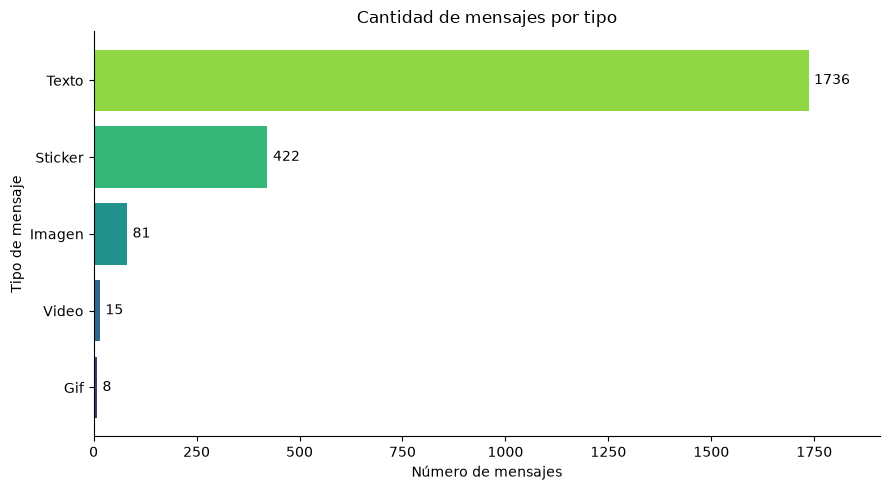

In [21]:
mensajes_por_tipo = df_usuarios["tipo"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(
    mensajes_por_tipo.index.str.capitalize(),
    mensajes_por_tipo.values,
    color=sns.color_palette("viridis", len(mensajes_por_tipo))
)

ax.bar_label(barras, padding=4, fmt="%d")
ax.set_title("Cantidad de mensajes por tipo")
ax.set_xlabel("Número de mensajes")
ax.set_ylabel("Tipo de mensaje")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, mensajes_por_tipo.max() * 1.1)

plt.tight_layout()
plt.show()

## Actividad por hora y día de la semana

Las siguientes gráficas consideran todos los tipos de mensaje enviados por los participantes.

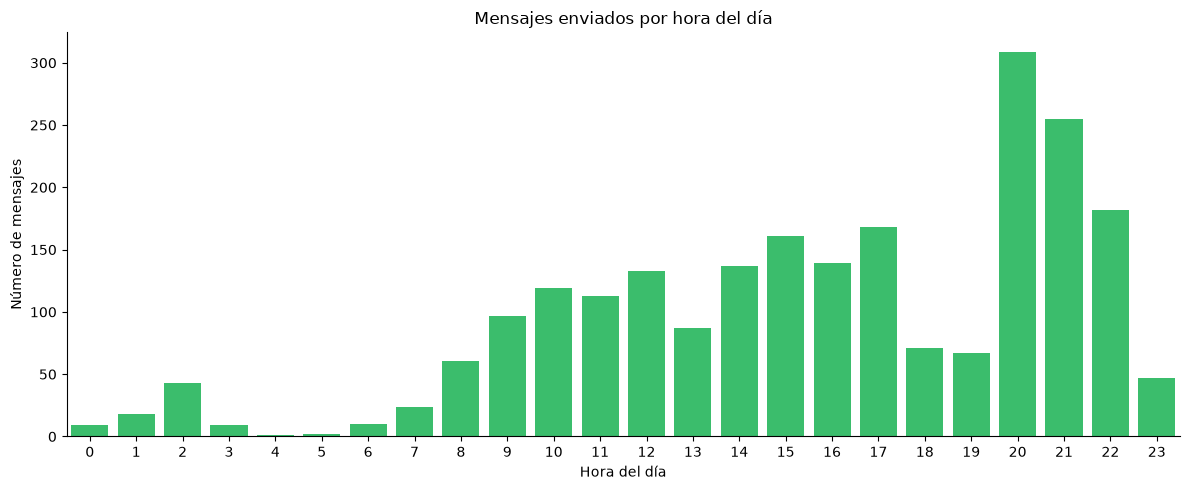

In [22]:
mensajes_por_hora = (
    df_usuarios["timestamp"].dt.hour
    .value_counts()
    .reindex(range(24), fill_value=0)
    .rename_axis("hora")
    .reset_index(name="mensajes")
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=mensajes_por_hora,
    x="hora",
    y="mensajes",
    color="#25D366",
    ax=ax
)

ax.set_title("Mensajes enviados por hora del día")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Número de mensajes")
ax.set_xticks(range(24))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

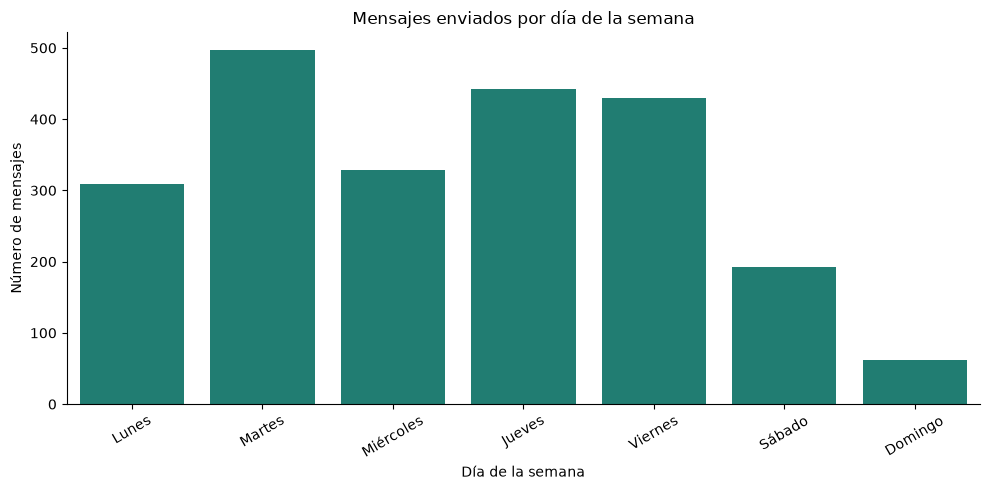

In [23]:
dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
mensajes_por_dia = (
    df_usuarios["timestamp"].dt.dayofweek
    .value_counts()
    .reindex(range(7), fill_value=0)
    .rename_axis("numero_dia")
    .reset_index(name="mensajes")
)
mensajes_por_dia["dia"] = mensajes_por_dia["numero_dia"].map(dict(enumerate(dias)))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=mensajes_por_dia,
    x="dia",
    y="mensajes",
    color="#128C7E",
    ax=ax
)

ax.set_title("Mensajes enviados por día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Número de mensajes")
ax.tick_params(axis="x", rotation=30)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## cual es el usuario que envia mas mensajes??


In [24]:
mensajes_por_usuario = (
    df_usuarios["usuario"]
    .value_counts()
    .reset_index()
)

mensajes_por_usuario.columns = ["usuario", "mensajes"]

mensajes_por_usuario.head(10)

,usuario,mensajes
0,+52 1 662 449 3477,186
1,+52 1 631 125 1255,173
2,+52 1 662 342 4670,135
3,+52 1 662 467 9029,126
4,+52 1 662 637 5722,108
5,+52 1 662 341 2644,71
6,+52 1 645 107 9121,65
7,+52 1 662 335 9011,55
8,+52 1 662 367 8720,48
9,+52 1 662 501 3191,48


### top usuarios (15)

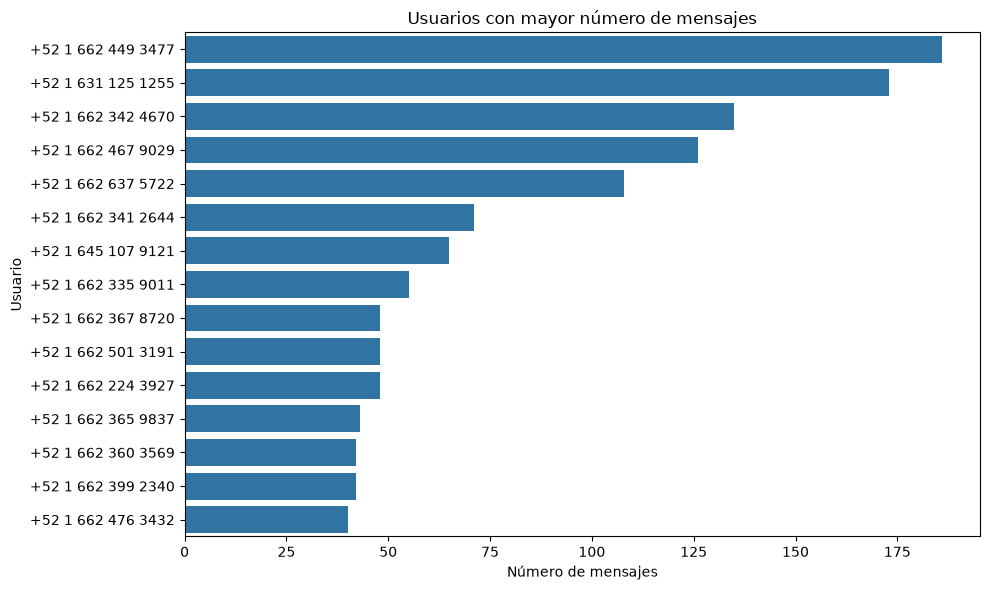

In [25]:
top_usuarios = mensajes_por_usuario.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_usuarios,
    x="mensajes",
    y="usuario"
)

plt.title("Usuarios con mayor número de mensajes")
plt.xlabel("Número de mensajes")
plt.ylabel("Usuario")

plt.tight_layout()
plt.show()

In [26]:
usuario_mas_activo = mensajes_por_usuario.iloc[0]

print("Usuario con más mensajes:", usuario_mas_activo["usuario"])
print("Mensajes enviados:", usuario_mas_activo["mensajes"])

Usuario con más mensajes: +52 1 662 449 3477
Mensajes enviados: 186


In [27]:
porcentaje = (
    usuario_mas_activo["mensajes"]
    / len(df_usuarios)
    * 100
)

print(f"Representa el {porcentaje:.2f}% de los mensajes del grupo.")

Representa el 8.22% de los mensajes del grupo.
